In [1]:
!pip install aif360 shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 6.1 MB/s eta 0:00:00


In [2]:
print("AIF360 and SHAP installed successfully!")

AIF360 and SHAP installed successfully!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from aif360.metrics import (
    BinaryLabelDatasetMetric,
    ClassificationMetric
)
from aif360.algorithms.preprocessing import Reweighing
import shap
print("all libraries imported successfully! ")

all libraries imported successfully! 


In [13]:
from aif360.datasets import AdultDataset

adult_dataset = AdultDataset()

print(
    "Dataset loaded successfully!"
)

print(
    "Dataset shape:",
    adult_dataset.features.shape
)

print(
    "Feature names:",
    adult_dataset.feature_names
)

Dataset loaded successfully!
Dataset shape: (45222, 98)
Feature names: ['age', 'education-num', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass=Federal-gov', 'workclass=Local-gov', 'workclass=Private', 'workclass=Self-emp-inc', 'workclass=Self-emp-not-inc', 'workclass=State-gov', 'workclass=Without-pay', 'education=10th', 'education=11th', 'education=12th', 'education=1st-4th', 'education=5th-6th', 'education=7th-8th', 'education=9th', 'education=Assoc-acdm', 'education=Assoc-voc', 'education=Bachelors', 'education=Doctorate', 'education=HS-grad', 'education=Masters', 'education=Preschool', 'education=Prof-school', 'education=Some-college', 'marital-status=Divorced', 'marital-status=Married-AF-spouse', 'marital-status=Married-civ-spouse', 'marital-status=Married-spouse-absent', 'marital-status=Never-married', 'marital-status=Separated', 'marital-status=Widowed', 'occupation=Adm-clerical', 'occupation=Armed-Forces', 'occupation=Craft-repair', 'occupation=Exec

In [14]:
#female is the unpriviledged group
unpriviledged_groups =[
    {"sex": 0}
]
# male is the priviledged group
priviledged_groups =[
    {"sex": 1}
]
print(
    "Gender groups defined succeffulyy"
)

Gender groups defined succeffulyy


In [11]:
# Download the Adult Income dataset files
# into the folder expected by AIF360

!mkdir -p /usr/local/lib/python3.12/dist-packages/aif360/data/raw/adult

!wget -q \
https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data \
-O /usr/local/lib/python3.12/dist-packages/aif360/data/raw/adult/adult.data

!wget -q \
https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test \
-O /usr/local/lib/python3.12/dist-packages/aif360/data/raw/adult/adult.test

!wget -q \
https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names \
-O /usr/local/lib/python3.12/dist-packages/aif360/data/raw/adult/adult.names

print("Adult dataset files downloaded successfully!")

Adult dataset files downloaded successfully!


In [17]:
!ls -lh /usr/local/lib/python3.12/dist-packages/aif360/data/raw/adult


total 5.8M
-rw-r--r-- 1 root root 3.8M Aug  1 12:03 adult.data
-rw-r--r-- 1 root root 5.2K Aug  1 12:03 adult.names
-rw-r--r-- 1 root root 2.0M Aug  1 12:03 adult.test
-rw-r--r-- 1 root root 1.1K Aug  1 11:22 README.md


In [18]:
from aif360.datasets import AdultDataset

adult_dataset = AdultDataset()

print("Dataset loaded successfully!")

print(
    "Dataset shape:",
    adult_dataset.features.shape
)

print(
    "Feature names:",
    adult_dataset.feature_names
)

Dataset loaded successfully!
Dataset shape: (45222, 98)
Feature names: ['age', 'education-num', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass=Federal-gov', 'workclass=Local-gov', 'workclass=Private', 'workclass=Self-emp-inc', 'workclass=Self-emp-not-inc', 'workclass=State-gov', 'workclass=Without-pay', 'education=10th', 'education=11th', 'education=12th', 'education=1st-4th', 'education=5th-6th', 'education=7th-8th', 'education=9th', 'education=Assoc-acdm', 'education=Assoc-voc', 'education=Bachelors', 'education=Doctorate', 'education=HS-grad', 'education=Masters', 'education=Preschool', 'education=Prof-school', 'education=Some-college', 'marital-status=Divorced', 'marital-status=Married-AF-spouse', 'marital-status=Married-civ-spouse', 'marital-status=Married-spouse-absent', 'marital-status=Never-married', 'marital-status=Separated', 'marital-status=Widowed', 'occupation=Adm-clerical', 'occupation=Armed-Forces', 'occupation=Craft-repair', 'occupation=Exec

In [19]:
# Female = unprivileged group

unprivileged_groups = [
    {"sex": 0}
]


# Male = privileged group

privileged_groups = [
    {"sex": 1}
]


print("Gender groups defined successfully!")

Gender groups defined successfully!


In [20]:
from aif360.metrics import BinaryLabelDatasetMetric

fairness_metric = BinaryLabelDatasetMetric(
    adult_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

disparate_impact = (
    fairness_metric.disparate_impact()
)

print(
    "Disparate Impact:",
    disparate_impact
)

Disparate Impact: 0.3634695423643793


In [21]:
# Split the dataset into training and testing data

train_data, test_data = adult_dataset.split(
    [0.7],
    shuffle=True,
    seed=42
)

print(
    "Training samples:",
    train_data.features.shape[0]
)

print(
    "Testing samples:",
    test_data.features.shape[0]
)

Training samples: 31655
Testing samples: 13567


In [22]:
# Training features and labels

X_train = train_data.features

y_train = train_data.labels.ravel()


# Testing features and labels

X_test = test_data.features

y_test = test_data.labels.ravel()


print(
    "Training data prepared successfully!"
)

print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_test shape:",
    X_test.shape
)

Training data prepared successfully!
X_train shape: (31655, 98)
X_test shape: (13567, 98)


In [23]:
from sklearn.preprocessing import StandardScaler

# Create the scaler

scaler = StandardScaler()


# Fit the scaler on training data

X_train_scaled = scaler.fit_transform(
    X_train
)


# Transform testing data

X_test_scaled = scaler.transform(
    X_test
)


print(
    "Data scaled successfully!"
)

Data scaled successfully!


In [24]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Train the model

model.fit(
    X_train_scaled,
    y_train
)


# Predict the test data

y_pred = model.predict(
    X_test_scaled
)


print(
    "Logistic Regression trained successfully!"
)

Logistic Regression trained successfully!


In [25]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "Model Accuracy:",
    accuracy
)


print(
    "\nClassification Report:\n"
)


print(
    classification_report(
        y_test,
        y_pred
    )
)

Model Accuracy: 0.8462445640156262

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.92      0.90     10195
         1.0       0.73      0.61      0.66      3372

    accuracy                           0.85     13567
   macro avg       0.80      0.77      0.78     13567
weighted avg       0.84      0.85      0.84     13567



In [26]:
#create a copy of the original test dataset
predicated_data = test_data.copy()
predicated_data.labels = y_pred.reshape(
    -1,
    1
)
print("prediction added successfully")

prediction added successfully


In [28]:
# Create a copy of the test dataset

predicted_data = test_data.copy()

# Add the Logistic Regression predictions

predicted_data.labels = y_pred.reshape(-1, 1)

print("Predicted dataset created successfully!")

Predicted dataset created successfully!


In [29]:
from aif360.metrics import ClassificationMetric

classification_metric = ClassificationMetric(
    test_data,
    predicted_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print(
    "Disparate Impact:",
    classification_metric.disparate_impact()
)

print(
    "Statistical Parity Difference:",
    classification_metric.statistical_parity_difference()
)

print(
    "Equal Opportunity Difference:",
    classification_metric.equal_opportunity_difference()
)

Disparate Impact: 0.3160801312889695
Statistical Parity Difference: -0.18316207931880174
Equal Opportunity Difference: -0.10433428906427045


In [30]:
from aif360.algorithms.preprocessing import Reweighing

# Create the Reweighing method

reweighing = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# Learn the weights and apply them
# only to the training dataset

reweighed_train_data = reweighing.fit_transform(
    train_data
)

print("Reweighing applied successfully!")

Reweighing applied successfully!


In [31]:
from sklearn.linear_model import LogisticRegression

# Create a new Logistic Regression model

reweighed_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the new sample weights

reweighed_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=reweighed_train_data.instance_weights
)

# Make predictions

reweighed_predictions = reweighed_model.predict(
    X_test_scaled
)

print("Reweighed model trained successfully!")

Reweighed model trained successfully!


In [32]:
from sklearn.metrics import accuracy_score

reweighed_accuracy = accuracy_score(
    y_test,
    reweighed_predictions
)

print(
    "Accuracy after Reweighing:",
    reweighed_accuracy
)

Accuracy after Reweighing: 0.8396108203729639


In [33]:
# Copy the original test data

reweighed_predicted_data = test_data.copy()

# Add the predictions from the reweighed model

reweighed_predicted_data.labels = (
    reweighed_predictions.reshape(-1, 1)
)

print(
    "Reweighed prediction dataset created!"
)

Reweighed prediction dataset created!


In [34]:
from aif360.metrics import ClassificationMetric

# Create a new fairness metric object

reweighed_metric = ClassificationMetric(
    test_data,
    reweighed_predicted_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# Print the new fairness results

print(
    "Disparate Impact after Reweighing:",
    reweighed_metric.disparate_impact()
)

print(
    "Statistical Parity Difference after Reweighing:",
    reweighed_metric.statistical_parity_difference()
)

print(
    "Equal Opportunity Difference after Reweighing:",
    reweighed_metric.equal_opportunity_difference()
)

Disparate Impact after Reweighing: 0.642117723128354
Statistical Parity Difference after Reweighing: -0.07712271020688091
Equal Opportunity Difference after Reweighing: 0.18421960135181736


In [35]:
# Create a fairness comparison table

fairness_comparison = pd.DataFrame({

    "Metric": [
        "Disparate Impact",
        "Statistical Parity Difference",
        "Equal Opportunity Difference"
    ],

    "Before Reweighing": [
        0.3160801312889695,
        -0.18316207931880174,
        -0.10433428906427045
    ],

    "After Reweighing": [
        0.642117723128354,
        -0.07712271020688091,
        0.18421960135181736
    ]

})

fairness_comparison

,Metric,Before Reweighing,After Reweighing
0,Disparate Impact,0.316080,0.642118
1,Statistical Parity Difference,-0.183162,-0.077123
2,Equal Opportunity Difference,-0.104334,0.184220


In [36]:
import shap

# Create an explainer for Logistic Regression

explainer = shap.LinearExplainer(
    model,
    X_train_scaled
)

# Calculate SHAP values

shap_values = explainer(
    X_test_scaled
)

print(
    "SHAP values generated successfully!"
)

SHAP values generated successfully!


In [37]:
# Convert the test data into a DataFrame
# so the feature names are visible

X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=adult_dataset.feature_names
)

print(
    "SHAP data prepared successfully!"
)

SHAP data prepared successfully!


/tmp/ipykernel_758/2055515522.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


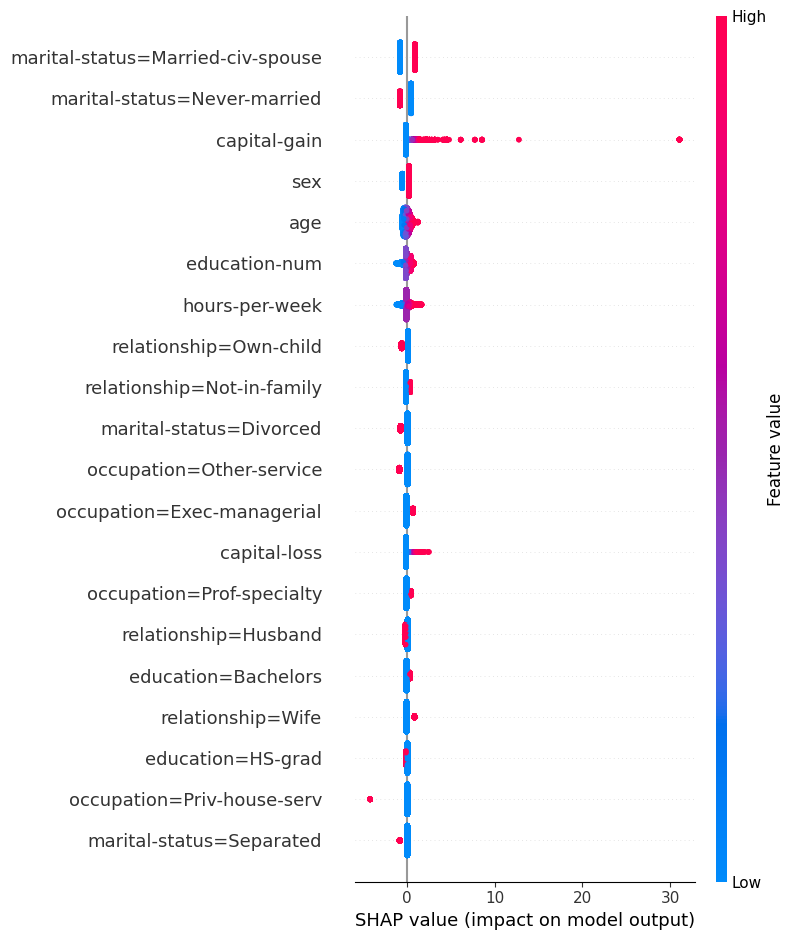

In [38]:
# Generate the SHAP summary plot

shap.summary_plot(
    shap_values.values,
    X_test_df
)

In [39]:
import shap
expplainer = shap.LinearExplainer(
    model,
    X_train_scaled
)
shap_values = explainer(
    X_test_scaled
)
print("SHAP values generated succefully")

SHAP values generated succefully


In [42]:
# Convert test data into a DataFrame
# so feature names appear on the graph

X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=adult_dataset.feature_names
)

print("Data prepared for SHAP plot!")

Data prepared for SHAP plot!


/tmp/ipykernel_758/2904899505.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


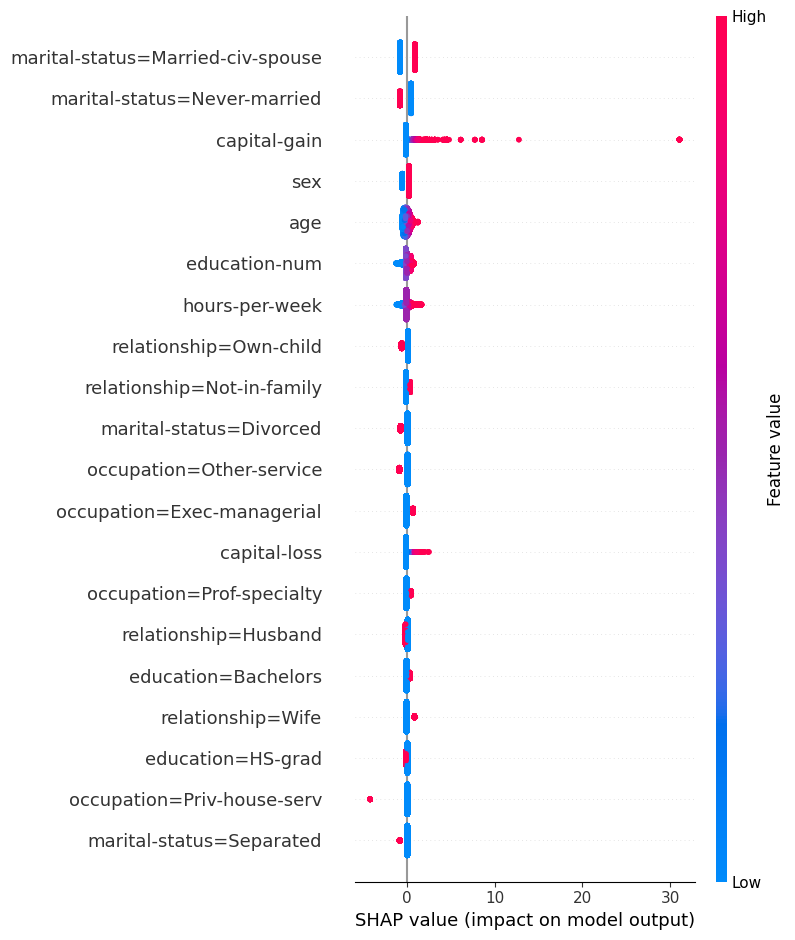

In [44]:
#generate hte shap summary plot
shap.summary_plot(
    shap_values.values,
    X_test_df
)

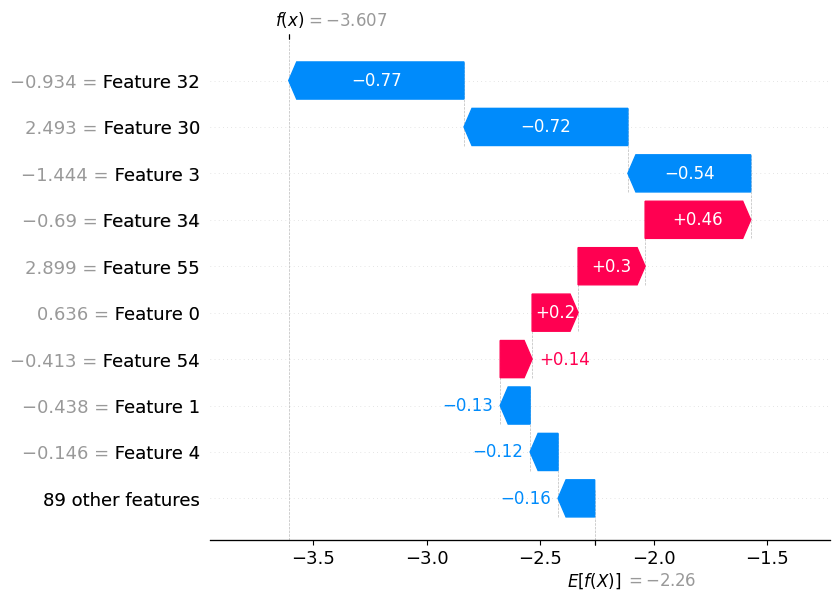

In [45]:
shap.plots.waterfall(
    shap_values[0]
)